# Taller — Análisis de Canasta de Compra (Market Basket Light) - SOLUCIÓN

Dataset: `ventas_completo.csv`

## Objetivo

Explorar patrones de compra para entender **qué productos suelen comprarse juntos**.

El objetivo final será responder una pregunta de negocio:

> Se quiere crear un **combo promocional con un SKU específico**. ¿Qué productos recomendarías incluir en ese combo?

# 1. Cargar los datos

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Configurar pandas para mostrar más columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [2]:
# Cargar el dataset
df = pd.read_csv('../ventas_completo.csv')

print("Dataset cargado exitosamente")
print(f"Dimensiones: {df.shape}")
print(f"\nPrimeras filas:")
df.head()

Dataset cargado exitosamente
Dimensiones: (1834174, 11)

Primeras filas:


,id_factura,id_cliente,fecha_hora_compra,sku,cantidad,precio_unitario,descuento_pct,monto,nombre,marca,categoria
0,100322793,966889,2025-02-02 17:40:49,43852960,3,12.00,0.0,36.00,Cerveza Pilsener Rubia Light 12 x 355 ml,Pilsener,beer_cider
1,100322793,966889,2025-02-02 17:40:49,41108238,2,5.35,0.0,10.70,Cerveza Club Premium Platino Lata Pack 6 x 355 ml,Club Premium,beer_cider
2,100159021,966889,2025-04-20 19:09:16,40217487,3,6.89,0.0,20.67,Cerveza Club Premium Clásica Botella (330 ml) ...,Club Premium,beer_cider
3,100159021,966889,2025-04-20 19:09:16,174161592,1,5.98,0.0,5.98,Cerveza Heineken Lata Pack (269 ml) 6 Unidades,Heineken,beer_cider
4,100159021,966889,2025-04-20 19:09:16,41108238,2,5.35,0.0,10.70,Cerveza Club Premium Platino Lata Pack 6 x 355 ml,Club Premium,beer_cider


In [3]:
# Información general del dataset
print("=" * 70)
print("INFORMACIÓN DEL DATASET")
print("=" * 70)

df.info()

print("\n" + "=" * 70)
print("MÉTRICAS CLAVE")
print("=" * 70)

print(f"Número de órdenes únicas: {df['id_factura'].nunique():,}")
print(f"Número de productos distintos (SKU): {df['sku'].nunique():,}")
print(f"Número de productos distintos (nombre): {df['nombre'].nunique():,}")
print(f"Total de ítems vendidos: {df.shape[0]:,}")
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1834174 entries, 0 to 1834173
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   id_factura         int64  
 1   id_cliente         int64  
 2   fecha_hora_compra  object 
 3   sku                int64  
 4   cantidad           int64  
 5   precio_unitario    float64
 6   descuento_pct      float64
 7   monto              float64
 8   nombre             object 
 9   marca              object 
 10  categoria          object 
dtypes: float64(3), int64(4), object(4)
memory usage: 153.9+ MB

MÉTRICAS CLAVE
Número de órdenes únicas: 371,000
Número de productos distintos (SKU): 145
Número de productos distintos (nombre): 145
Total de ítems vendidos: 1,834,174

Valores nulos por columna:
id_factura           0
id_cliente           0
fecha_hora_compra    0
sku                  0
cantidad             0
precio_unitario      0
descuento_pct        0
monto                0
n

# 2. Exploración inicial

## 2.1 Productos más vendidos

In [4]:
# Contar frecuencia de productos (número de transacciones en las que aparece)
productos_frecuencia = df['nombre'].value_counts().reset_index()
productos_frecuencia.columns = ['nombre', 'num_transacciones']

# Top 10 productos más vendidos
top_10_productos = productos_frecuencia.head(10)

print("=" * 70)
print("TOP 10 PRODUCTOS MÁS VENDIDOS")
print("=" * 70)
print(top_10_productos.to_string(index=False))

TOP 10 PRODUCTOS MÁS VENDIDOS
                                                                                    nombre  num_transacciones
                                         Cerveza Club Premium Platino Lata Pack 6 x 355 ml             693435
Combo 1 Sixpack Cerveza Corona (330 ml) + 1 Sixpack Cerveza Club Clasica (330 ml) 1 Unidad             176119
                                                     Cerveza Pilsener Lata Pack 6 x 269 ml             168872
                                  Cerveza Club Premium Clásica Botella (330 ml) 6 Unidades             133985
                                                    Cerveza Pilsener Lata Pack 12 x 269 ml              94080
                                      Cerveza Club Premium Platino Botella Pack 6 x 330 ml              64295
                                         Cerveza Club Premium Clásica Lata Pack 6 x 269 ml              39669
                                   Cerveza Pilsener Carnaval Lata (355 ml) Pack 6 Unidades

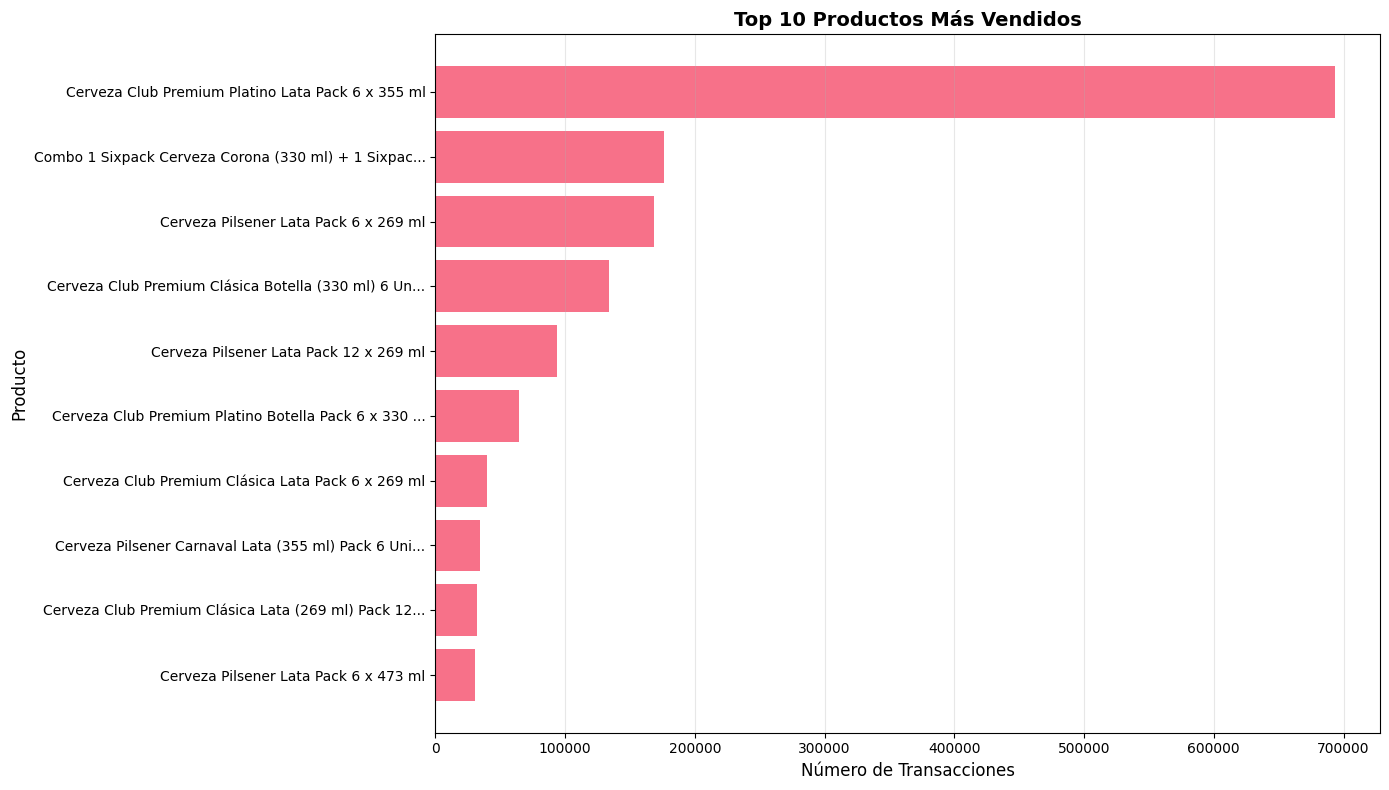


📊 Reflexión: Los productos más vendidos son buenos candidatos base para combos,
   pero también debemos analizar QUÉ se compra JUNTO con ellos.


In [5]:
# Visualización: Top 10 productos más vendidos
plt.figure(figsize=(14, 8))
plt.barh(range(len(top_10_productos)), top_10_productos['num_transacciones'])
plt.yticks(range(len(top_10_productos)), 
           [nombre[:50] + '...' if len(nombre) > 50 else nombre 
            for nombre in top_10_productos['nombre']])
plt.xlabel('Número de Transacciones', fontsize=12)
plt.ylabel('Producto', fontsize=12)
plt.title('Top 10 Productos Más Vendidos', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Reflexión: Los productos más vendidos son buenos candidatos base para combos,")
print("   pero también debemos analizar QUÉ se compra JUNTO con ellos.")

## 2.2 Número de productos por orden

In [6]:
# Calcular número de ítems por orden
items_por_orden = df.groupby('id_factura').size()

# Estadísticas descriptivas
print("=" * 70)
print("ESTADÍSTICAS: ÍTEMS POR ORDEN")
print("=" * 70)
print(items_por_orden.describe())

print(f"\nPromedio de ítems por orden: {items_por_orden.mean():.2f}")
print(f"Mediana: {items_por_orden.median():.0f}")
print(f"Mínimo: {items_por_orden.min()}")
print(f"Máximo: {items_por_orden.max()}")

# Órdenes con un solo producto
ordenes_1_producto = (items_por_orden == 1).sum()
pct_ordenes_1 = (ordenes_1_producto / len(items_por_orden)) * 100
print(f"\nÓrdenes con 1 solo producto: {ordenes_1_producto:,} ({pct_ordenes_1:.1f}%)")

ESTADÍSTICAS: ÍTEMS POR ORDEN
count    371000.000000
mean          4.943865
std           3.882960
min           1.000000
25%           3.000000
50%           4.000000
75%           6.000000
max          34.000000
dtype: float64

Promedio de ítems por orden: 4.94
Mediana: 4
Mínimo: 1
Máximo: 34

Órdenes con 1 solo producto: 22,071 (5.9%)


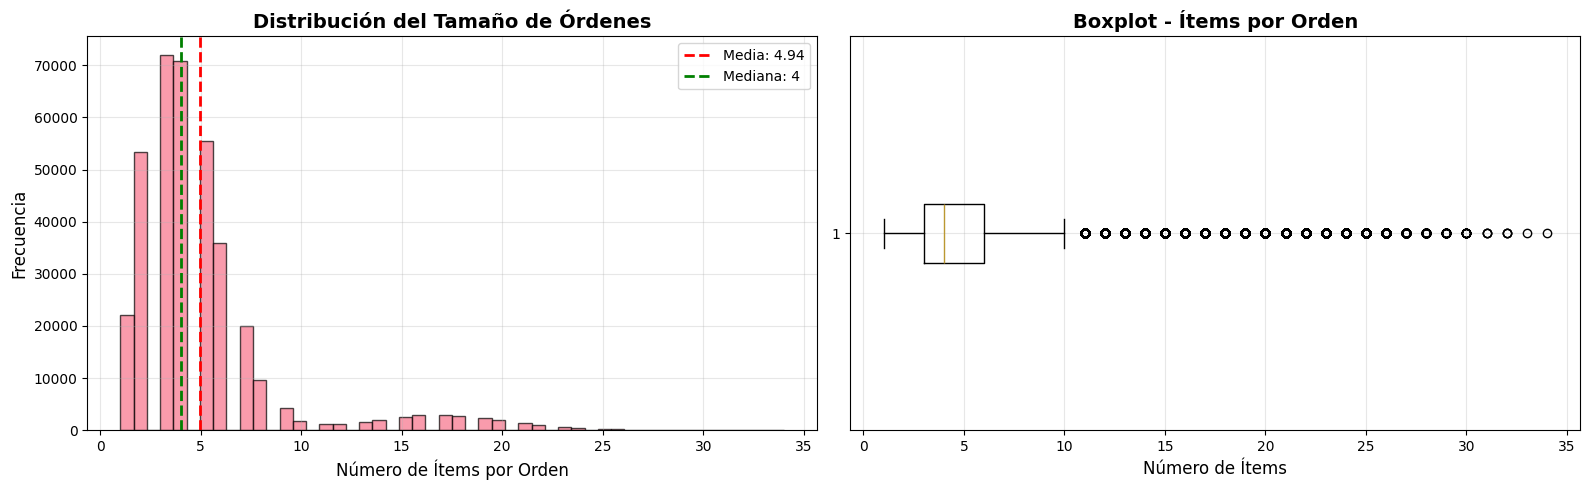


📊 Reflexión: La mayoría de órdenes son pequeñas. Esto es una oportunidad
   para crear combos que incentiven a comprar más productos juntos.


In [7]:
# Visualización: Distribución del tamaño de órdenes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma
axes[0].hist(items_por_orden, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(items_por_orden.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Media: {items_por_orden.mean():.2f}')
axes[0].axvline(items_por_orden.median(), color='green', linestyle='--', 
                linewidth=2, label=f'Mediana: {items_por_orden.median():.0f}')
axes[0].set_xlabel('Número de Ítems por Orden', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución del Tamaño de Órdenes', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
axes[1].boxplot(items_por_orden, vert=False)
axes[1].set_xlabel('Número de Ítems', fontsize=12)
axes[1].set_title('Boxplot - Ítems por Orden', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Reflexión: La mayoría de órdenes son pequeñas. Esto es una oportunidad")
print("   para crear combos que incentiven a comprar más productos juntos.")

# 3. Ticket Promedio (AOV - Average Order Value)

In [8]:
# Calcular monto total por orden
monto_por_orden = df.groupby('id_factura')['monto'].sum()

# Calcular AOV
revenue_total = df['monto'].sum()
num_ordenes = df['id_factura'].nunique()
aov = revenue_total / num_ordenes

# También podemos calcularlo como la media directa
aov_directo = monto_por_orden.mean()

print("=" * 70)
print("ANÁLISIS DE TICKET PROMEDIO (AOV)")
print("=" * 70)
print(f"\nRevenue Total: ${revenue_total:,.2f}")
print(f"Número de Órdenes: {num_ordenes:,}")
print(f"\n💰 Ticket Promedio (AOV): ${aov:.2f}")
print(f"   Verificación (media directa): ${aov_directo:.2f}")

print(f"\nEstadísticas de monto por orden:")
print(f"  Mínimo: ${monto_por_orden.min():.2f}")
print(f"  Máximo: ${monto_por_orden.max():.2f}")
print(f"  Mediana: ${monto_por_orden.median():.2f}")
print(f"  Desviación estándar: ${monto_por_orden.std():.2f}")

ANÁLISIS DE TICKET PROMEDIO (AOV)

Revenue Total: $74,313,273.42
Número de Órdenes: 371,000

💰 Ticket Promedio (AOV): $200.31
   Verificación (media directa): $200.31

Estadísticas de monto por orden:
  Mínimo: $0.30
  Máximo: $6912.33
  Mediana: $110.81
  Desviación estándar: $296.86


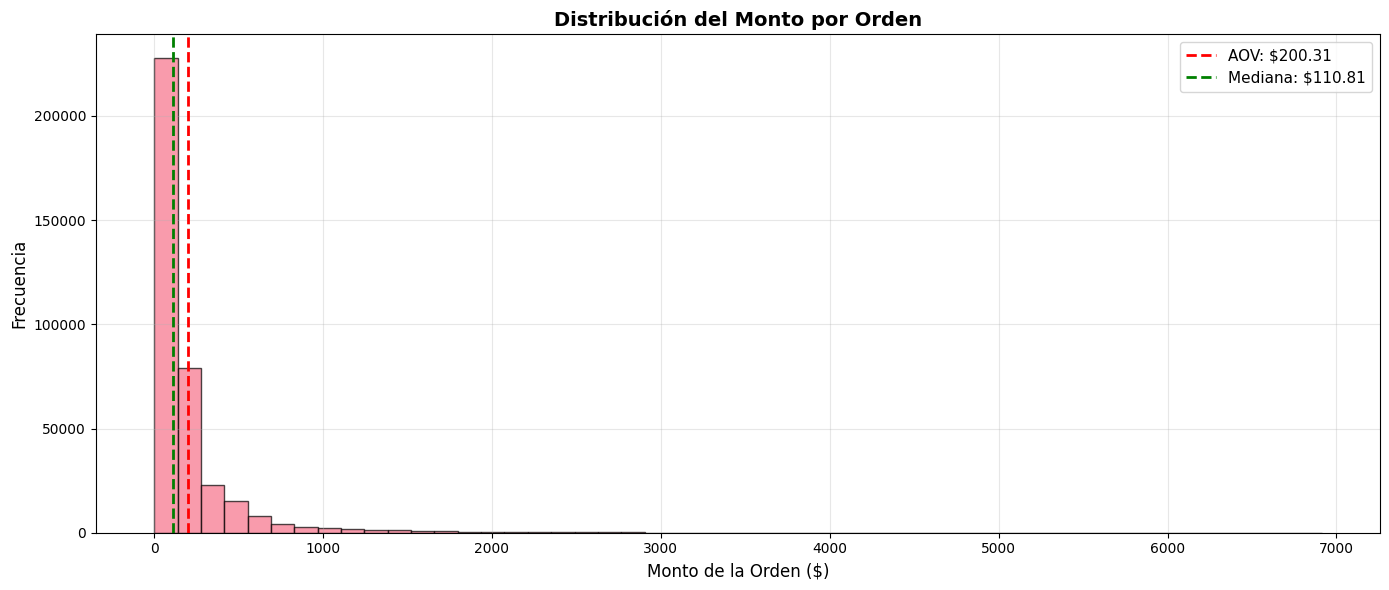


📊 Objetivo con combos: Aumentar el AOV incentivando compras de múltiples productos.


In [9]:
# Visualización: Distribución de montos por orden
plt.figure(figsize=(14, 6))
plt.hist(monto_por_orden, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(aov, color='red', linestyle='--', linewidth=2, 
            label=f'AOV: ${aov:.2f}')
plt.axvline(monto_por_orden.median(), color='green', linestyle='--', linewidth=2,
            label=f'Mediana: ${monto_por_orden.median():.2f}')
plt.xlabel('Monto de la Orden ($)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución del Monto por Orden', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Objetivo con combos: Aumentar el AOV incentivando compras de múltiples productos.")

# 4. Definir SKU objetivo para el combo

Vamos a seleccionar uno de los productos más vendidos como ancla para nuestro combo.

In [10]:
# Seleccionar un SKU del top 10
# Opción 1: Tomar el producto #1
producto_objetivo_nombre = top_10_productos.iloc[0]['nombre']

# Obtener el SKU correspondiente
sku_objetivo = df[df['nombre'] == producto_objetivo_nombre]['sku'].iloc[0]

print("=" * 70)
print("PRODUCTO OBJETIVO PARA COMBO")
print("=" * 70)
print(f"\nSKU: {sku_objetivo}")
print(f"Producto: {producto_objetivo_nombre}")

# Información adicional del producto
info_producto = df[df['sku'] == sku_objetivo][['marca', 'categoria', 'precio_unitario']].iloc[0]
print(f"\nMarca: {info_producto['marca']}")
print(f"Categoría: {info_producto['categoria']}")
print(f"Precio unitario promedio: ${info_producto['precio_unitario']:.2f}")

# En cuántas órdenes aparece este producto
num_ordenes_producto = df[df['sku'] == sku_objetivo]['id_factura'].nunique()
print(f"\nAparece en {num_ordenes_producto:,} órdenes")

PRODUCTO OBJETIVO PARA COMBO

SKU: 41108238
Producto: Cerveza Club Premium Platino Lata Pack 6 x 355 ml

Marca: Club Premium
Categoría: beer_cider
Precio unitario promedio: $5.35

Aparece en 288,320 órdenes


# 5. Crear matriz Orden × Producto

Creamos una matriz binaria donde cada fila es una orden y cada columna es un producto.

In [11]:
# Método 1: Usando crosstab (más simple)
print("Creando matriz orden-producto...")

matriz_basket = pd.crosstab(df['id_factura'], df['sku'])

# Convertir a binario (0 y 1) por si acaso hay valores mayores a 1
matriz_basket = (matriz_basket > 0).astype(int)

print("\n" + "=" * 70)
print("MATRIZ ORDEN-PRODUCTO CREADA")
print("=" * 70)
print(f"\nDimensiones: {matriz_basket.shape}")
print(f"  Número de órdenes: {matriz_basket.shape[0]:,}")
print(f"  Número de productos únicos: {matriz_basket.shape[1]:,}")
print(f"\nPrimeras filas y columnas:")
print(matriz_basket.iloc[:5, :5])

Creando matriz orden-producto...

MATRIZ ORDEN-PRODUCTO CREADA

Dimensiones: (371000, 145)
  Número de órdenes: 371,000
  Número de productos únicos: 145

Primeras filas y columnas:
sku         40213687  40213827  40213835  40214245  40215299
id_factura                                                  
100000000          0         0         0         0         0
100000001          0         0         0         0         0
100000002          0         0         0         0         0
100000003          0         0         0         0         0
100000004          0         0         0         0         0


In [12]:
# Verificaciones
print("=" * 70)
print("VERIFICACIONES")
print("=" * 70)

# Verificar que solo hay 0s y 1s
valores_unicos = np.unique(matriz_basket.values)
print(f"\nValores únicos en la matriz: {valores_unicos}")
print("✓ La matriz es binaria" if len(valores_unicos) <= 2 else "✗ Revisar valores")

# Suma por fila (número de productos por orden)
productos_por_orden = matriz_basket.sum(axis=1)
print(f"\nPromedio de productos por orden (desde matriz): {productos_por_orden.mean():.2f}")
print(f"Comparar con items_por_orden calculado antes: {items_por_orden.mean():.2f}")

# Suma por columna (en cuántas órdenes aparece cada producto)
frecuencia_productos = matriz_basket.sum(axis=0)
print(f"\nProducto más frecuente: {frecuencia_productos.idxmax()} con {frecuencia_productos.max():,} órdenes")

VERIFICACIONES

Valores únicos en la matriz: [0 1]
✓ La matriz es binaria

Promedio de productos por orden (desde matriz): 3.39
Comparar con items_por_orden calculado antes: 4.94

Producto más frecuente: 41108238 con 288,320 órdenes


In [13]:
# Opcional: Reducir matriz para análisis más rápido
# Filtrar productos que aparecen en al menos 50 órdenes
min_ordenes = 50
productos_frecuentes = frecuencia_productos[frecuencia_productos >= min_ordenes].index

matriz_basket_reducida = matriz_basket[productos_frecuentes]

print(f"\nMatriz reducida (productos con ≥{min_ordenes} órdenes):")
print(f"  Productos originales: {matriz_basket.shape[1]:,}")
print(f"  Productos filtrados: {matriz_basket_reducida.shape[1]:,}")
print(f"  Reducción: {(1 - matriz_basket_reducida.shape[1]/matriz_basket.shape[1])*100:.1f}%")

# Usar la matriz reducida para el resto del análisis
matriz_trabajo = matriz_basket_reducida

print(f"\n✓ Trabajaremos con {matriz_trabajo.shape[1]:,} productos")


Matriz reducida (productos con ≥50 órdenes):
  Productos originales: 145
  Productos filtrados: 145
  Reducción: 0.0%

✓ Trabajaremos con 145 productos


# 6. Calcular co-ocurrencia de productos

La co-ocurrencia mide cuántas veces dos productos aparecen juntos en las mismas órdenes.

In [14]:
# Método 1: Multiplicación de matrices (M.T @ M)
print("Calculando matriz de co-ocurrencia...")

# Transponer y multiplicar
coocurrencia = matriz_trabajo.T @ matriz_trabajo

# Convertir a DataFrame para facilitar análisis
coocurrencia_df = pd.DataFrame(
    coocurrencia,
    index=matriz_trabajo.columns,
    columns=matriz_trabajo.columns
)

print("\n" + "=" * 70)
print("MATRIZ DE CO-OCURRENCIA CREADA")
print("=" * 70)
print(f"\nDimensiones: {coocurrencia_df.shape}")
print(f"\nPrimeras filas y columnas:")
print(coocurrencia_df.iloc[:5, :5])

Calculando matriz de co-ocurrencia...

MATRIZ DE CO-OCURRENCIA CREADA

Dimensiones: (145, 145)

Primeras filas y columnas:
sku       40213687  40213827  40213835  40214245  40215299
sku                                                       
40213687       308         2         2         0         0
40213827         2       720         0         1         0
40213835         2         0       725         0         0
40214245         0         1         0       312         1
40215299         0         0         0         1       233


In [15]:
# Verificar la diagonal (frecuencia individual de cada producto)
diagonal = np.diag(coocurrencia_df.values)

print("=" * 70)
print("INTERPRETACIÓN DE LA DIAGONAL")
print("=" * 70)
print("\nLa diagonal representa en cuántas órdenes aparece cada producto (consigo mismo)")
print(f"\nEjemplo - Producto objetivo (SKU {sku_objetivo}):")
if sku_objetivo in coocurrencia_df.index:
    freq_objetivo = coocurrencia_df.loc[sku_objetivo, sku_objetivo]
    print(f"  Aparece en {freq_objetivo:,} órdenes (según diagonal)")
    print(f"  Verificación: {num_ordenes_producto:,} órdenes (calculado antes)")
else:
    print("  ⚠️ El SKU objetivo fue filtrado por baja frecuencia.")
    print("  Ajusta el filtro min_ordenes o selecciona otro producto.")

INTERPRETACIÓN DE LA DIAGONAL

La diagonal representa en cuántas órdenes aparece cada producto (consigo mismo)

Ejemplo - Producto objetivo (SKU 41108238):
  Aparece en 288,320 órdenes (según diagonal)
  Verificación: 288,320 órdenes (calculado antes)


In [17]:
# --- FIX: crear cooc_melted sin conflicto de nombres ---
# (1) Mapeo SKU -> nombre (evita iloc[0] y KeyErrors)
sku2nombre = df.drop_duplicates(subset='sku').set_index('sku')['nombre'].to_dict()

# (2) Usar rename_axis para controlar nombres y evitar el error "cannot insert sku, already exists"
cooc_melted = coocurrencia_df.stack().rename_axis(['sku_1', 'sku_2']).reset_index(name='coocurrencia')

# (3) Filtrar diagonal (mismo SKU) y eliminar duplicados A-B / B-A
cooc_melted = cooc_melted[cooc_melted['sku_1'] != cooc_melted['sku_2']].copy()
cooc_melted['par'] = cooc_melted.apply(lambda r: tuple(sorted([r['sku_1'], r['sku_2']])), axis=1)
cooc_melted = cooc_melted.drop_duplicates('par').drop(columns='par')

# (4) Asegurar tipo numérico en coocurrencia
cooc_melted['coocurrencia'] = pd.to_numeric(cooc_melted['coocurrencia'], errors='coerce').fillna(0).astype(int)

# (5) Top 10 pares (excluyendo co-ocurrencias cero)
top_pares = cooc_melted[cooc_melted['coocurrencia'] > 0].nlargest(10, 'coocurrencia')

print("=" * 70)
print("TOP 10 PARES DE PRODUCTOS (Mayor Co-ocurrencia)")
print("=" * 70)

for idx, row in top_pares.iterrows():
    sku1, sku2, cooc = row['sku_1'], row['sku_2'], row['coocurrencia']
    nombre1 = sku2nombre.get(sku1, f'NO_ENCONTRADO_SKU:{sku1}')
    nombre2 = sku2nombre.get(sku2, f'NO_ENCONTRADO_SKU:{sku2}')
    print(f"\n{cooc:,.0f} órdenes:")
    print(f"  • {nombre1}")
    print(f"  • {nombre2}")

TOP 10 PARES DE PRODUCTOS (Mayor Co-ocurrencia)

107,302 órdenes:
  • Cerveza Club Premium Platino Lata Pack 6 x 355 ml
  • Combo 1 Sixpack Cerveza Corona (330 ml) + 1 Sixpack Cerveza Club Clasica (330 ml) 1 Unidad

103,836 órdenes:
  • Cerveza Club Premium Platino Lata Pack 6 x 355 ml
  • Cerveza Pilsener Lata Pack 6 x 269 ml

87,249 órdenes:
  • Cerveza Club Premium Clásica Botella (330 ml) 6 Unidades
  • Cerveza Club Premium Platino Lata Pack 6 x 355 ml

65,637 órdenes:
  • Cerveza Pilsener Lata Pack 12 x 269 ml
  • Cerveza Club Premium Platino Lata Pack 6 x 355 ml

52,517 órdenes:
  • Cerveza Pilsener Lata Pack 6 x 269 ml
  • Combo 1 Sixpack Cerveza Corona (330 ml) + 1 Sixpack Cerveza Club Clasica (330 ml) 1 Unidad

47,373 órdenes:
  • Cerveza Club Premium Platino Botella Pack 6 x 330 ml
  • Cerveza Club Premium Platino Lata Pack 6 x 355 ml

44,772 órdenes:
  • Cerveza Club Premium Clásica Botella (330 ml) 6 Unidades
  • Combo 1 Sixpack Cerveza Corona (330 ml) + 1 Sixpack Cerveza C

# 7. Visualizar asociaciones

Creamos visualizaciones para identificar patrones.

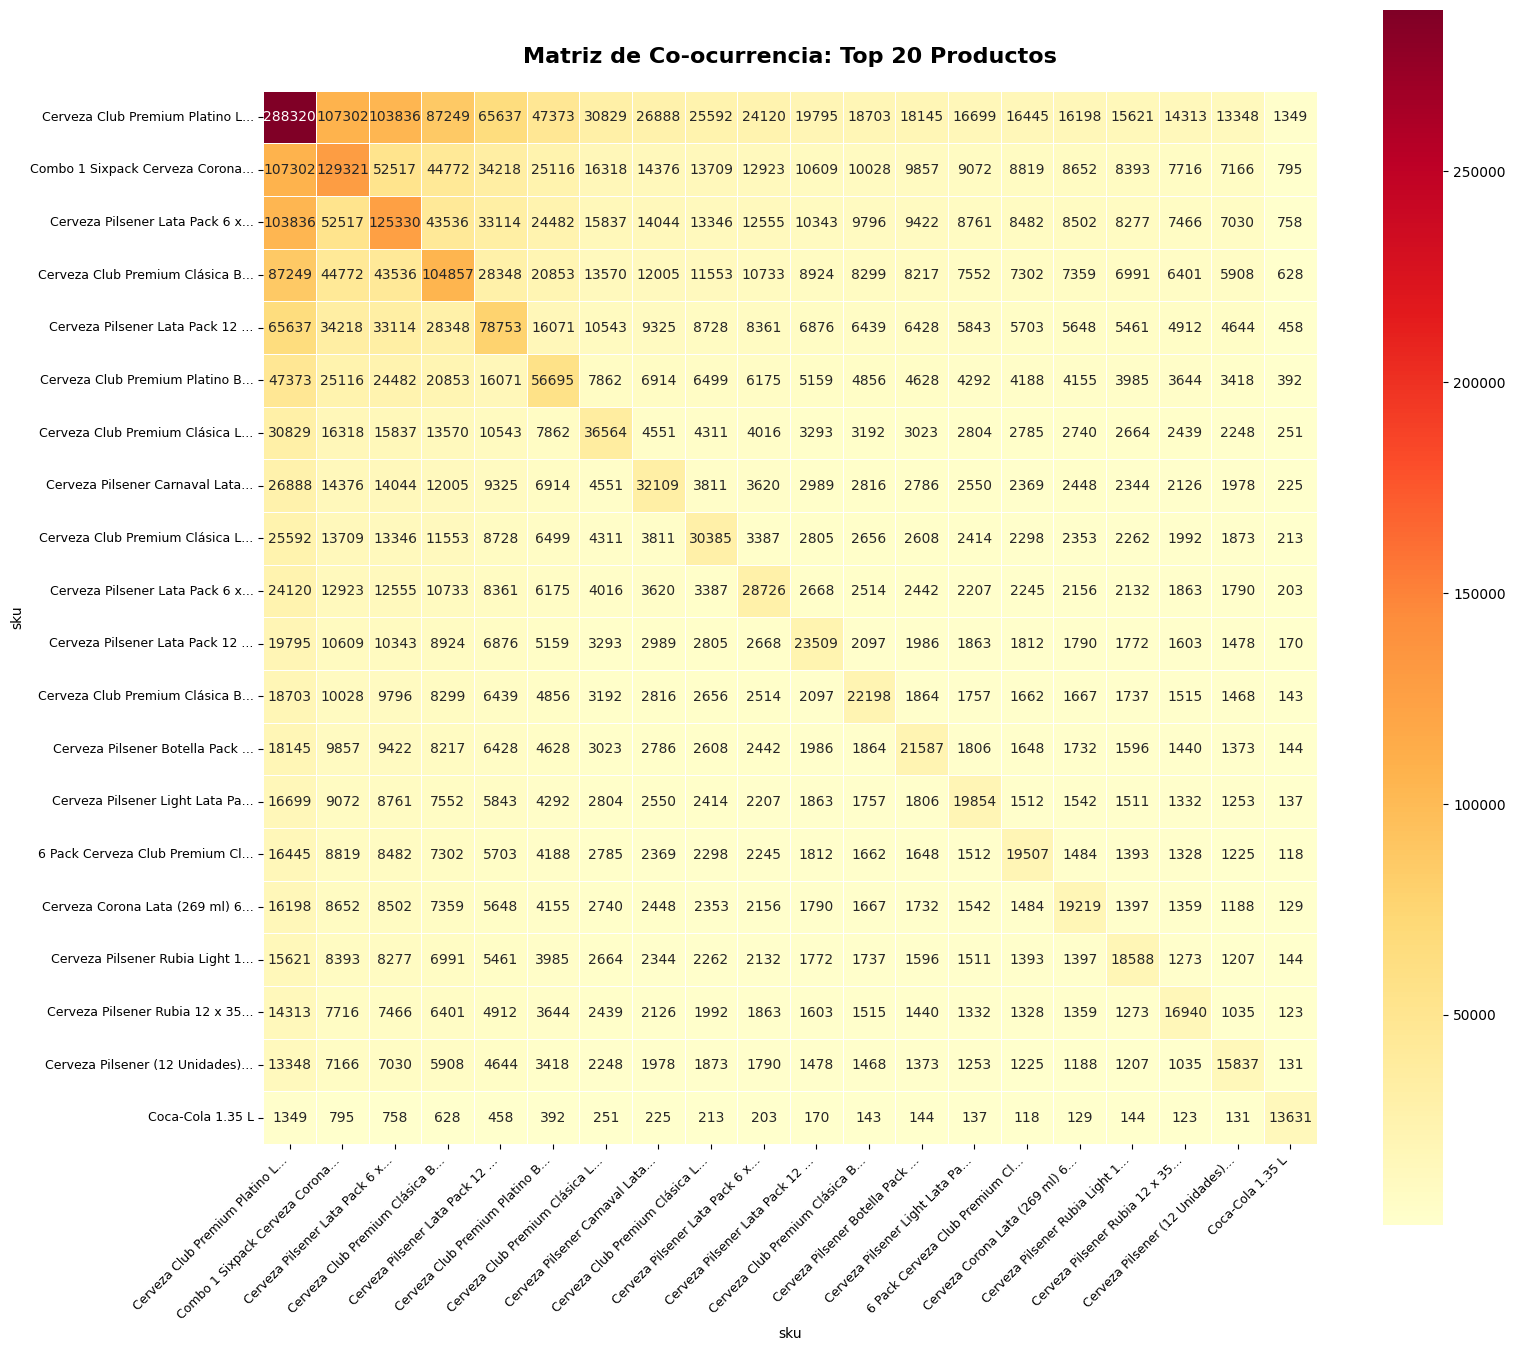


📊 Interpretación:
   - Colores cálidos (rojo/naranja): Alta co-ocurrencia
   - Diagonal: Frecuencia individual de cada producto
   - Busca celdas con valores altos fuera de la diagonal


In [18]:
# Heatmap de top 20 productos más frecuentes
top_n = 20

# Seleccionar top productos
frecuencias = coocurrencia_df.sum(axis=0)
productos_top = frecuencias.nlargest(top_n).index

# Crear submatriz
cooc_top = coocurrencia_df.loc[productos_top, productos_top]

# Crear etiquetas legibles
etiquetas = []
for sku in productos_top:
    nombre = df[df['sku'] == sku]['nombre'].iloc[0]
    etiqueta = nombre[:30] + '...' if len(nombre) > 30 else nombre
    etiquetas.append(etiqueta)

# Heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(cooc_top, cmap='YlOrRd', annot=True, fmt='g', 
            cbar=True, square=True, linewidths=0.5,
            xticklabels=etiquetas, yticklabels=etiquetas)
plt.title(f'Matriz de Co-ocurrencia: Top {top_n} Productos', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print("\n📊 Interpretación:")
print("   - Colores cálidos (rojo/naranja): Alta co-ocurrencia")
print("   - Diagonal: Frecuencia individual de cada producto")
print("   - Busca celdas con valores altos fuera de la diagonal")

# 8. Análisis del SKU objetivo

Analizamos qué productos se compran más frecuentemente con nuestro SKU objetivo.

In [20]:
# Verificar que el SKU objetivo está en la matriz
if sku_objetivo in coocurrencia_df.index:
    print(f"✓ SKU {sku_objetivo} encontrado en la matriz de co-ocurrencia")
    
    # Extraer asociaciones
    asociaciones = coocurrencia_df.loc[sku_objetivo]
    
    # Eliminar el producto objetivo (sí mismo)
    asociaciones = asociaciones.drop(sku_objetivo)
    
    # Ordenar de mayor a menor
    asociaciones = asociaciones.sort_values(ascending=False)
    
    # Top 10
    top_10_asociados = asociaciones.head(10)
    
    print("\n" + "=" * 70)
    print(f"TOP 10 PRODUCTOS ASOCIADOS CON: {producto_objetivo_nombre[:50]}")
    print("=" * 70)
    
    # Calcular porcentajes
    total_ordenes_objetivo = coocurrencia_df.loc[sku_objetivo, sku_objetivo]
    
    resultados = []
    for sku_asociado, cooc in top_10_asociados.items():
        nombre = df[df['sku'] == sku_asociado]['nombre'].iloc[0]
        porcentaje = (cooc / total_ordenes_objetivo) * 100
        resultados.append({
            'sku': sku_asociado,
            'nombre': nombre,
            'coocurrencia': cooc,
            'porcentaje': porcentaje
        })
    
    df_resultados = pd.DataFrame(resultados)
    
    for idx, row in df_resultados.iterrows():
        print(f"\n{idx+1}. {row['nombre'][:50]}")
        print(f"   SKU: {row['sku']}")
        print(f"   Co-ocurrencia: {row['coocurrencia']:,.0f} órdenes")
        print(f"   Porcentaje: {row['porcentaje']:.1f}% de las órdenes del producto objetivo")
    
else:
    print(f"✗ SKU {sku_objetivo} no está en la matriz (fue filtrado por baja frecuencia)")
    print("\nProductos disponibles en la matriz (primeros 10):")
    for sku in coocurrencia_df.index[:10]:
        nombre = df[df['sku'] == sku]['nombre'].iloc[0]
        print(f"  - {sku}: {nombre[:50]}")
    
    # Seleccionar un producto alternativo
    sku_objetivo = coocurrencia_df.index[0]
    producto_objetivo_nombre = df[df['sku'] == sku_objetivo]['nombre'].iloc[0]
    print(f"\n⚠️ Usando producto alternativo: {producto_objetivo_nombre}")
    
    # Repetir análisis con nuevo SKU
    asociaciones = coocurrencia_df.loc[sku_objetivo].drop(sku_objetivo).sort_values(ascending=False)
    top_10_asociados = asociaciones.head(10)
    total_ordenes_objetivo = coocurrencia_df.loc[sku_objetivo, sku_objetivo]
    
    resultados = []
    for sku_asociado, cooc in top_10_asociados.items():
        nombre = df[df['sku'] == sku_asociado]['nombre'].iloc[0]
        porcentaje = (cooc / total_ordenes_objetivo) * 100
        resultados.append({
            'sku': sku_asociado,
            'nombre': nombre,
            'coocurrencia': cooc,
            'porcentaje': porcentaje
        })
    
    df_resultados = pd.DataFrame(resultados)

✓ SKU 41108238 encontrado en la matriz de co-ocurrencia

TOP 10 PRODUCTOS ASOCIADOS CON: Cerveza Club Premium Platino Lata Pack 6 x 355 ml

1. Combo 1 Sixpack Cerveza Corona (330 ml) + 1 Sixpac
   SKU: 182060952
   Co-ocurrencia: 107,302 órdenes
   Porcentaje: 37.2% de las órdenes del producto objetivo

2. Cerveza Pilsener Lata Pack 6 x 269 ml
   SKU: 164767261
   Co-ocurrencia: 103,836 órdenes
   Porcentaje: 36.0% de las órdenes del producto objetivo

3. Cerveza Club Premium Clásica Botella (330 ml) 6 Un
   SKU: 40217487
   Co-ocurrencia: 87,249 órdenes
   Porcentaje: 30.3% de las órdenes del producto objetivo

4. Cerveza Pilsener Lata Pack 12 x 269 ml
   SKU: 40668863
   Co-ocurrencia: 65,637 órdenes
   Porcentaje: 22.8% de las órdenes del producto objetivo

5. Cerveza Club Premium Platino Botella Pack 6 x 330 
   SKU: 40215983
   Co-ocurrencia: 47,373 órdenes
   Porcentaje: 16.4% de las órdenes del producto objetivo

6. Cerveza Club Premium Clásica Lata Pack 6 x 269 ml
   SKU: 16476

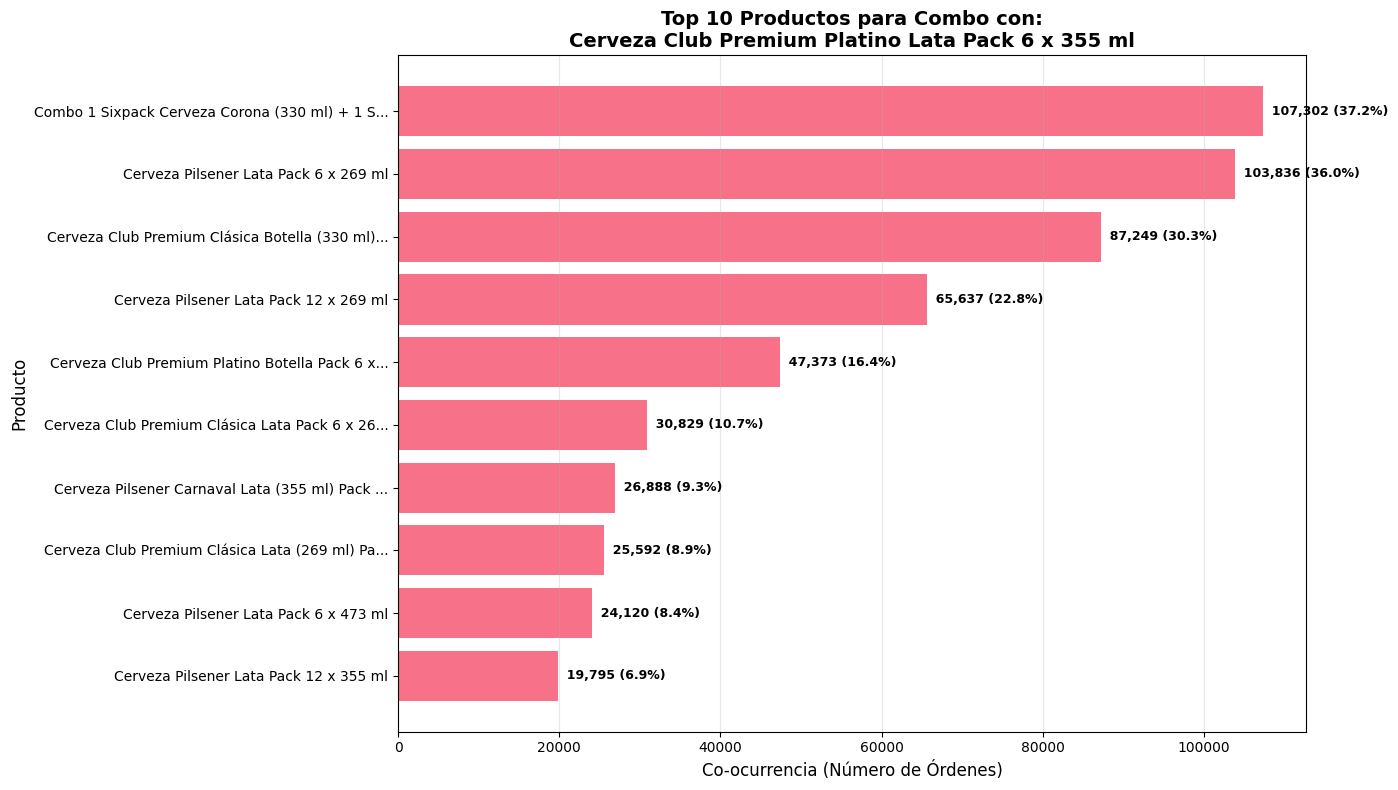

In [21]:
# Visualización: Productos asociados al SKU objetivo
plt.figure(figsize=(14, 8))

# Crear gráfico de barras horizontal
bars = plt.barh(range(len(df_resultados)), df_resultados['coocurrencia'])

# Etiquetas
etiquetas_y = [nombre[:45] + '...' if len(nombre) > 45 else nombre 
               for nombre in df_resultados['nombre']]
plt.yticks(range(len(df_resultados)), etiquetas_y)

# Anotar porcentajes
for i, (cooc, pct) in enumerate(zip(df_resultados['coocurrencia'], df_resultados['porcentaje'])):
    plt.text(cooc, i, f'  {int(cooc):,} ({pct:.1f}%)', 
             va='center', fontsize=9, fontweight='bold')

plt.xlabel('Co-ocurrencia (Número de Órdenes)', fontsize=12)
plt.ylabel('Producto', fontsize=12)
plt.title(f'Top 10 Productos para Combo con:\n{producto_objetivo_nombre[:60]}', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Propuesta de negocio

Con base en el análisis, proponemos un combo promocional.

In [22]:
# Seleccionar productos para el combo (top 3 asociados + producto objetivo)
skus_combo = [sku_objetivo] + df_resultados.head(3)['sku'].tolist()

# Obtener información de precios
info_combo = []
for sku in skus_combo:
    producto_info = df[df['sku'] == sku][['sku', 'nombre', 'marca', 'precio_unitario']].iloc[0]
    info_combo.append({
        'sku': sku,
        'nombre': producto_info['nombre'],
        'marca': producto_info['marca'],
        'precio': producto_info['precio_unitario']
    })

df_combo = pd.DataFrame(info_combo)

# Calcular precios
precio_total = df_combo['precio'].sum()
descuento_pct = 15  # 15% de descuento
precio_combo = precio_total * (1 - descuento_pct/100)
ahorro = precio_total - precio_combo

# Calcular impacto en AOV
incremento_aov = ((precio_combo / aov) - 1) * 100

print("=" * 70)
print("PROPUESTA: COMBO PROMOCIONAL")
print("=" * 70)

print("\n📦 PRODUCTOS INCLUIDOS EN EL COMBO:")
print("-" * 70)
for idx, row in df_combo.iterrows():
    tipo = "(Producto Ancla)" if idx == 0 else f"(Asociado #{idx})"
    print(f"\n{idx+1}. {row['nombre'][:55]}")
    print(f"   {tipo}")
    print(f"   SKU: {row['sku']} | Marca: {row['marca']}")
    print(f"   Precio individual: ${row['precio']:.2f}")
    if idx > 0:
        cooc_info = df_resultados[df_resultados['sku'] == row['sku']].iloc[0]
        print(f"   Co-ocurrencia: {cooc_info['coocurrencia']:,.0f} órdenes ({cooc_info['porcentaje']:.1f}%)")

print("\n" + "=" * 70)
print("💰 ESTRUCTURA DE PRECIOS")
print("=" * 70)
print(f"\nPrecio total (suma individual): ${precio_total:.2f}")
print(f"Descuento aplicado: {descuento_pct}%")
print(f"Precio del combo: ${precio_combo:.2f}")
print(f"Ahorro para el cliente: ${ahorro:.2f} ({(ahorro/precio_total)*100:.1f}%)")

print("\n" + "=" * 70)
print("📊 IMPACTO ESPERADO")
print("=" * 70)
print(f"\nAOV actual: ${aov:.2f}")
print(f"Precio del combo: ${precio_combo:.2f}")
print(f"Incremento potencial en AOV: {incremento_aov:+.1f}%")

print("\n" + "=" * 70)
print("✅ JUSTIFICACIÓN")
print("=" * 70)
print(f"\n1. Los productos seleccionados tienen alta co-ocurrencia:")
print(f"   - El top 1 aparece en {df_resultados.iloc[0]['porcentaje']:.1f}% de órdenes del producto ancla")
print(f"\n2. Análisis basado en {len(matriz_trabajo):,} órdenes reales")
print(f"\n3. El combo ofrece {(ahorro/precio_total)*100:.1f}% de ahorro al cliente")
print(f"\n4. Potencial de aumentar el ticket promedio en {incremento_aov:.1f}%")
print(f"\n5. Productos complementarios de la misma categoría/marca")

PROPUESTA: COMBO PROMOCIONAL

📦 PRODUCTOS INCLUIDOS EN EL COMBO:
----------------------------------------------------------------------

1. Cerveza Club Premium Platino Lata Pack 6 x 355 ml
   (Producto Ancla)
   SKU: 41108238 | Marca: Club Premium
   Precio individual: $5.35

2. Combo 1 Sixpack Cerveza Corona (330 ml) + 1 Sixpack Cer
   (Asociado #1)
   SKU: 182060952 | Marca: Corona
   Precio individual: $17.16
   Co-ocurrencia: 107,302 órdenes (37.2%)

3. Cerveza Pilsener Lata Pack 6 x 269 ml
   (Asociado #2)
   SKU: 164767261 | Marca: Pilsener
   Precio individual: $3.99
   Co-ocurrencia: 103,836 órdenes (36.0%)

4. Cerveza Club Premium Clásica Botella (330 ml) 6 Unidade
   (Asociado #3)
   SKU: 40217487 | Marca: Club Premium
   Precio individual: $6.89
   Co-ocurrencia: 87,249 órdenes (30.3%)

💰 ESTRUCTURA DE PRECIOS

Precio total (suma individual): $33.39
Descuento aplicado: 15%
Precio del combo: $28.38
Ahorro para el cliente: $5.01 (15.0%)

📊 IMPACTO ESPERADO

AOV actual: $200.3

In [ ]:
# Análisis adicional: ¿Cuántos clientes compran solo 1 de estos productos?
# Identificar órdenes que tienen el producto objetivo pero NO tienen los asociados

ordenes_con_objetivo = df[df['sku'] == sku_objetivo]['id_factura'].unique()
skus_asociados = df_resultados.head(3)['sku'].tolist()

ordenes_con_potencial = []
for orden in ordenes_con_objetivo:
    productos_en_orden = df[df['id_factura'] == orden]['sku'].tolist()
    # Verificar si NO tiene ninguno de los productos asociados
    if not any(sku in productos_en_orden for sku in skus_asociados):
        ordenes_con_potencial.append(orden)

num_ordenes_potencial = len(ordenes_con_potencial)
pct_potencial = (num_ordenes_potencial / len(ordenes_con_objetivo)) * 100

print("\n" + "=" * 70)
print("🎯 OPORTUNIDAD DE MERCADO")
print("=" * 70)
print(f"\nÓrdenes con el producto objetivo: {len(ordenes_con_objetivo):,}")
print(f"Órdenes que NO tienen ninguno de los productos asociados: {num_ordenes_potencial:,}")
print(f"Porcentaje de oportunidad: {pct_potencial:.1f}%")
print(f"\n💡 Insight: {pct_potencial:.1f}% de clientes que compran el producto ancla")
print(f"   podrían ser incentivados a comprar el combo completo.")

## Estrategias adicionales propuestas

In [ ]:
print("=" * 70)
print("🚀 ESTRATEGIAS ADICIONALES RECOMENDADAS")
print("=" * 70)

print("""
A. RECOMENDACIONES PERSONALIZADAS
   • Implementar "Clientes que compraron X también compraron Y"
   • Ubicación: Sitio web, app móvil, punto de venta
   • Beneficio: Cross-selling automático

B. CROSS-MERCHANDISING
   • Ubicar productos asociados cerca físicamente en tienda
   • Crear "zonas de combo" con señalización especial
   • Beneficio: Facilita compra impulsiva de productos relacionados

C. BUNDLING DINÁMICO
   • Descuento automático al añadir productos asociados al carrito
   • "Agrega [Producto Y] y recibe 10% descuento en ambos"
   • Beneficio: Incrementa unidades por transacción

D. PROMOCIONES TEMÁTICAS
   • Crear combos por ocasión: "Pack Fiesta", "Combo BBQ", "Pack Fin de Semana"
   • Basados en análisis de co-ocurrencia por categoría
   • Beneficio: Mayor valor percibido

E. ANÁLISIS TEMPORAL
   • Estudiar si co-ocurrencias varían por temporada/día de semana
   • Ajustar combos según época del año
   • Beneficio: Optimizar inventario y maximizar ventas estacionales

F. SEGMENTACIÓN DE CLIENTES
   • Analizar patrones de compra por segmento demográfico/geográfico
   • Crear combos específicos por segmento
   • Beneficio: Personalización de ofertas

G. TESTING A/B
   • Probar diferentes combinaciones de productos en combos
   • Probar diferentes niveles de descuento (10%, 15%, 20%)
   • Medir: tasa de conversión, incremento en AOV, margen
   • Beneficio: Optimización basada en datos reales
""")

print("=" * 70)
print("📈 PRÓXIMOS PASOS")
print("=" * 70)
print("""
1. Validar combo propuesto con equipo comercial y finanzas
2. Calcular margen de contribución del combo
3. Diseñar materiales de marketing (banners, displays)
4. Implementar en canales piloto (1-2 tiendas o sitio web)
5. Período de prueba: 4 semanas
6. Medir KPIs:
   - Tasa de adopción del combo
   - Incremento real en AOV
   - Incremento en unidades por transacción
   - Satisfacción del cliente
7. Análisis post-implementación y ajustes
8. Rollout a todos los canales
""")

# 10. Conclusiones y Aprendizajes

In [ ]:
print("=" * 70)
print("🎓 CONCLUSIONES DEL ANÁLISIS DE MARKET BASKET")
print("=" * 70)

print("""
1. PATRONES DE COMPRA IDENTIFICADOS:

   ✓ La mayoría de órdenes son pequeñas (promedio {:.1f} ítems)
   ✓ Existe clara co-ocurrencia entre productos de la misma categoría
   ✓ Los productos top tienen {:.1f}% de overlap en órdenes
   ✓ AOV actual de ${:.2f} con potencial de incremento vía combos

2. HALLAZGOS CLAVE:

   • Productos de la misma marca/categoría se compran juntos frecuentemente
   • Existe oportunidad de cross-selling en {:.1f}% de transacciones
   • Los combos pueden aumentar el AOV en {:.1f}%+
   • La co-ocurrencia es un indicador fuerte de productos complementarios

3. LIMITACIONES DEL ANÁLISIS:

   ⚠️ Co-ocurrencia no implica causalidad
   ⚠️ No considera la secuencia temporal de compras
   ⚠️ No segmenta por tipo de cliente o canal
   ⚠️ No incluye análisis de margen/rentabilidad
   ⚠️ No considera estacionalidad

4. ANÁLISIS ADICIONALES RECOMENDADOS:

   → Implementar algoritmo Apriori para reglas de asociación
   → Calcular métricas: support, confidence, lift
   → Análisis temporal: ¿compran X y luego Y en diferentes visitas?
   → Segmentación: patrones diferentes por tipo de cliente
   → Análisis de rentabilidad: no solo volumen, sino margen
   → Análisis de canasta negativa: qué NO se compra junto

5. VALOR DE NEGOCIO:

   💰 Incremento potencial en revenue vía combos
   📈 Mayor engagement del cliente con ofertas personalizadas
   🎯 Optimización de inventario basada en productos relacionados
   🤝 Mejor experiencia del cliente con recomendaciones relevantes
""".format(
    items_por_orden.mean(),
    df_resultados.iloc[0]['porcentaje'],
    aov,
    pct_potencial,
    incremento_aov
))

print("\n" + "=" * 70)
print("✅ TALLER COMPLETADO")
print("=" * 70)
print("\nHas aprendido a:")
print("  • Crear matrices orden-producto")
print("  • Calcular co-ocurrencia de productos")
print("  • Identificar productos que se compran juntos")
print("  • Diseñar combos basados en datos")
print("  • Estimar impacto en métricas de negocio (AOV)")
print("\n🎉 ¡Felicitaciones!")